# Regression with a Tabular Media Campaign Cost Dataset  

This project involves predicting outcomes related to media campaign costs using regression techniques. The dataset provides features and target values that enable analysis and model building to understand the relationship between variables.  

## Dataset  
The dataset for this project can be accessed at the following link:  
[**Media Campaign Cost Dataset**](https://www.kaggle.com/competitions/playground-series-s3e11/data)  


In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression  
from sklearn.metrics import mean_squared_log_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor


from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error, mean_squared_log_error


In [5]:
train =pd.read_csv("train.csv")
test =pd.read_csv("test.csv")

In [13]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 360336 entries, 0 to 360335
Data columns (total 17 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   id                          360336 non-null  int64  
 1   store_sales(in millions)    360336 non-null  float64
 2   unit_sales(in millions)     360336 non-null  float64
 3   total_children              360336 non-null  float64
 4   num_children_at_home        360336 non-null  float64
 5   avg_cars_at home(approx).1  360336 non-null  float64
 6   gross_weight                360336 non-null  float64
 7   recyclable_package          360336 non-null  float64
 8   low_fat                     360336 non-null  float64
 9   units_per_case              360336 non-null  float64
 10  store_sqft                  360336 non-null  float64
 11  coffee_bar                  360336 non-null  float64
 12  video_store                 360336 non-null  float64
 13  salad_bar     

In [15]:
train.isnull().sum()

id                            0
store_sales(in millions)      0
unit_sales(in millions)       0
total_children                0
num_children_at_home          0
avg_cars_at home(approx).1    0
gross_weight                  0
recyclable_package            0
low_fat                       0
units_per_case                0
store_sqft                    0
coffee_bar                    0
video_store                   0
salad_bar                     0
prepared_food                 0
florist                       0
cost                          0
dtype: int64

Text(0.5, 1.0, 'Box plot of Cost')

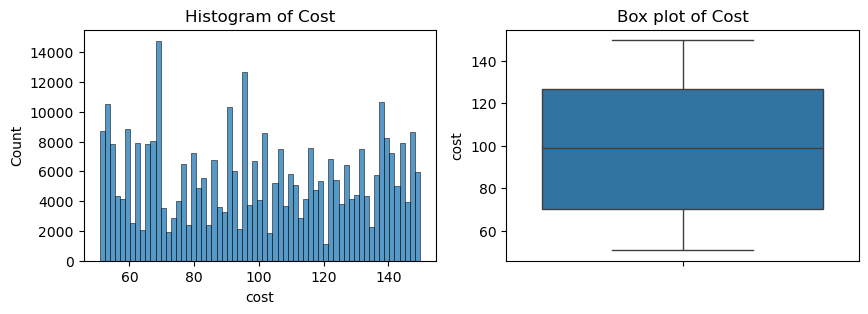

In [23]:
fig,axes = plt.subplots(1,2, figsize=(10,3))
sns.histplot(train['cost'], ax=axes[0])
axes[0].set_title('Histogram of Cost')
sns.boxplot(train['cost'], ax=axes[1])
axes[1].set_title('Box plot of Cost')

In [29]:
X_train, X_val, y_train, y_val = train_test_split(train.drop(['cost'],axis=1),train['cost'],test_size=0.2)

In [35]:
lr = LinearRegression()
lr.fit(X_train,y_train)
pred = lr.predict(X_val)
mean_squared_log_error(y_val, pred)

0.10087913054945966

In [39]:
tree = DecisionTreeRegressor()
tree.fit(X_train,y_train)
pred = tree.predict(X_val)
mean_squared_log_error(y_val, pred)

0.17693390950650192

In [41]:
knn=KNeighborsRegressor()
knn.fit(X_train,y_train)
pred = knn.predict(X_val)
mean_squared_log_error(y_val,pred)

0.11389926748410203

In [42]:
my_pred = lr.predict(test)
df = pd.DataFrame({'id': test['id'], 'target':my_pred})
df.to_csv('submission.csv',index= False)

## Conclusion  

In this project, the goal was to predict outcomes for a media campaign cost dataset using regression models. Several models were explored, including **Linear Regression**, **Decision Tree Regressor**, and **K-Nearest Neighbors Regressor (KNN)**.  

### Model Results:  
- **Linear Regression**: Achieved a Mean Squared Log Error (MSLE) of **0.1009** on the validation set.  
- **Decision Tree Regressor**: MSLE of **0.1769** on the validation set.  
- **K-Nearest Neighbors Regressor**: MSLE of **0.1139** on the validation set.  

Given the results, **Linear Regression** emerged as the most effective model for this dataset, balancing simplicity and performance.  

### Kaggle Submission:  
For the final Kaggle submission, the **Linear Regression** model was used, achieving a score of **0.3157**.  

This outcome demonstrates that linear models can effectively capture the relationships in tabular datasets when the underlying patterns are relatively simple and linear in nature. Future work could explore advanced ensemble methods or feature engineering to further enhance the model's performance.  
